<a href="https://colab.research.google.com/github/JoelRomero123/datamining/blob/main/ARCHIVOS/Prestige.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
# 1. Cargar el archivo CSV

url="https://raw.githubusercontent.com/JoelRomero123/datamining/refs/heads/main/ARCHIVOS/Prestige_modificado.csv"
df=pd.read_csv(url, sep=';')

# Convertir columnas a tipo numérico, forzando errores a NaN si es necesario
numeric_cols = ['education', 'income', 'women', 'prestige', 'census', 'type_num']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [ ]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())


(102, 1)
  occupation;education;income;women;prestige;census;type_num
0   gov.administrators;13.11;12351;11.16;68.8;1113;1        
1      general.managers;12.26;25879;4.02;69.1;1130;1        
2            accountants;12.77;9271;15.7;63.4;1171;1        
3    purchasing.officers;11.42;8865;9.11;56.8;1175;1        
4              chemists;14.62;8403;11.68;73.5;2111;1        
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 1 columns):
 #   Column                                                      Non-Null Count  Dtype 
---  ------                                                      --------------  ----- 
 0   occupation;education;income;women;prestige;census;type_num  102 non-null    object
dtypes: object(1)
memory usage: 948.0+ bytes
None
occupation;education;income;women;prestige;census;type_num    0
dtype: int64
0
       occupation;education;income;women;prestige;census;type_num
count                                                 102     

In [ ]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

In [ ]:
matriz_correlacion = variables_numericas.corr()

In [ ]:
print(df.columns)

Index(['occupation', 'education', 'income', 'women', 'prestige', 'census',
       'type_num'],
      dtype='object')


In [ ]:
import matplotlib.pyplot as plt

plt.figure()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

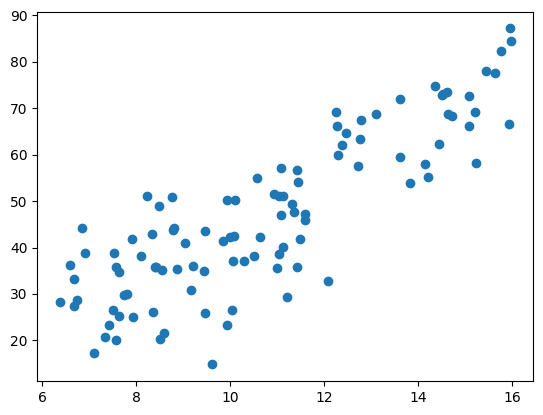

In [ ]:
plt.scatter(df['education'], df['prestige'])

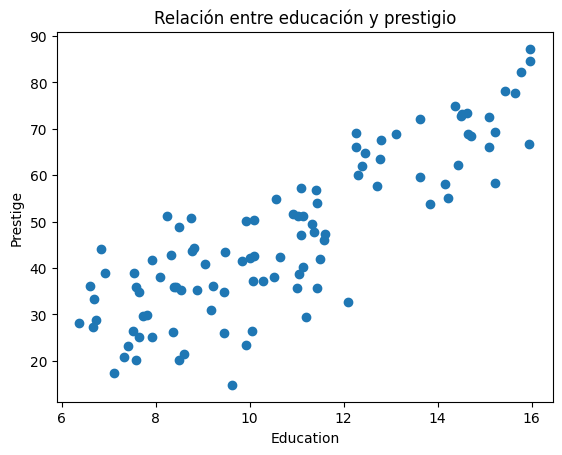

In [ ]:
plt.figure()
plt.scatter(df['education'], df['prestige'])
plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Relación entre educación y prestigio')
plt.show()

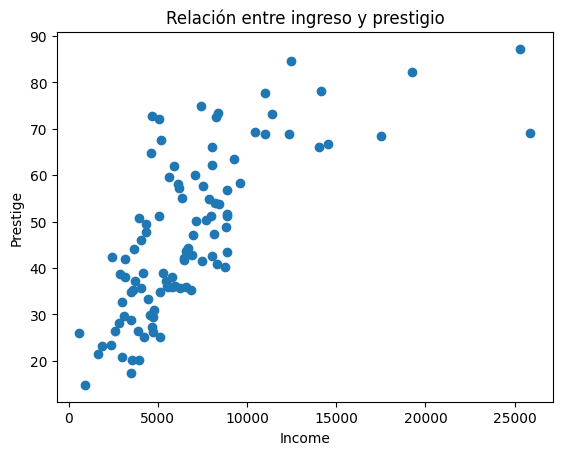

In [ ]:
plt.figure()
plt.scatter(df['income'], df['prestige'])
plt.xlabel('Income')
plt.ylabel('Prestige')
plt.title('Relación entre ingreso y prestigio')
plt.show()

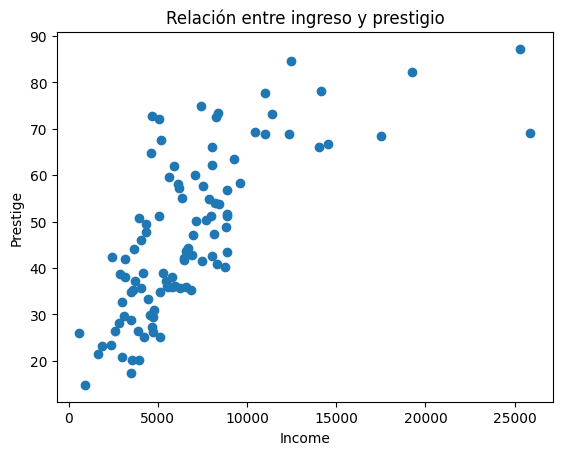

In [ ]:
plt.figure()
plt.scatter(df['income'], df['prestige'])
plt.xlabel('Income')
plt.ylabel('Prestige')
plt.title('Relación entre ingreso y prestigio')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

In [ ]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)


In [ ]:
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)


In [ ]:
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)


In [ ]:
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


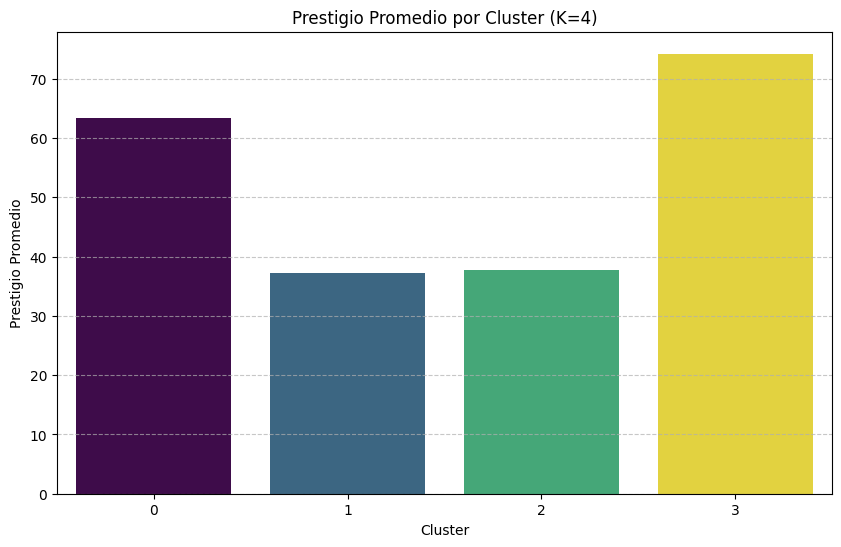

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prestigio promedio por Cluster_4
prestige_por_cluster_4 = df.groupby('Cluster_4')['prestige'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster_4', y='prestige', data=prestige_por_cluster_4, palette='viridis', hue='Cluster_4', legend=False)
plt.title('Prestigio Promedio por Cluster (K=4)')
plt.xlabel('Cluster')
plt.ylabel('Prestigio Promedio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

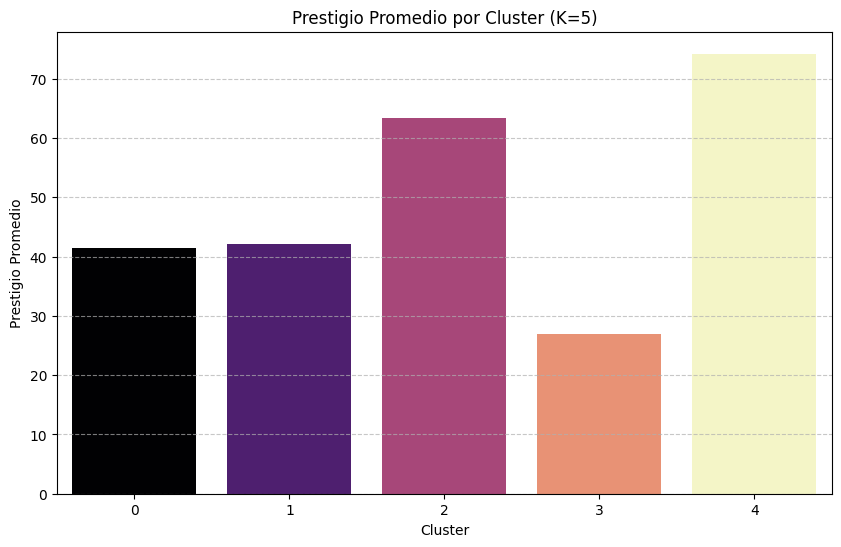

In [ ]:
# Prestigio promedio por Cluster_5
prestige_por_cluster_5 = df.groupby('Cluster_5')['prestige'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster_5', y='prestige', data=prestige_por_cluster_5, palette='magma', hue='Cluster_5', legend=False)
plt.title('Prestigio Promedio por Cluster (K=5)')
plt.xlabel('Cluster')
plt.ylabel('Prestigio Promedio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Select numeric variables
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
matriz_correlacion = variables_numericas.corr()

# Display the correlation matrix
print(matriz_correlacion)

           education    income     women  prestige    census  type_num
education   1.000000  0.577580  0.061853  0.850177 -0.823088 -0.381865
income      0.577580  1.000000 -0.441059  0.714906 -0.361002 -0.368360
women       0.061853 -0.441059  1.000000 -0.118334 -0.227003  0.250952
prestige    0.850177  0.714906 -0.118334  1.000000 -0.634510 -0.464762
census     -0.823088 -0.361002 -0.227003 -0.634510  1.000000  0.288078
type_num   -0.381865 -0.368360  0.250952 -0.464762  0.288078  1.000000


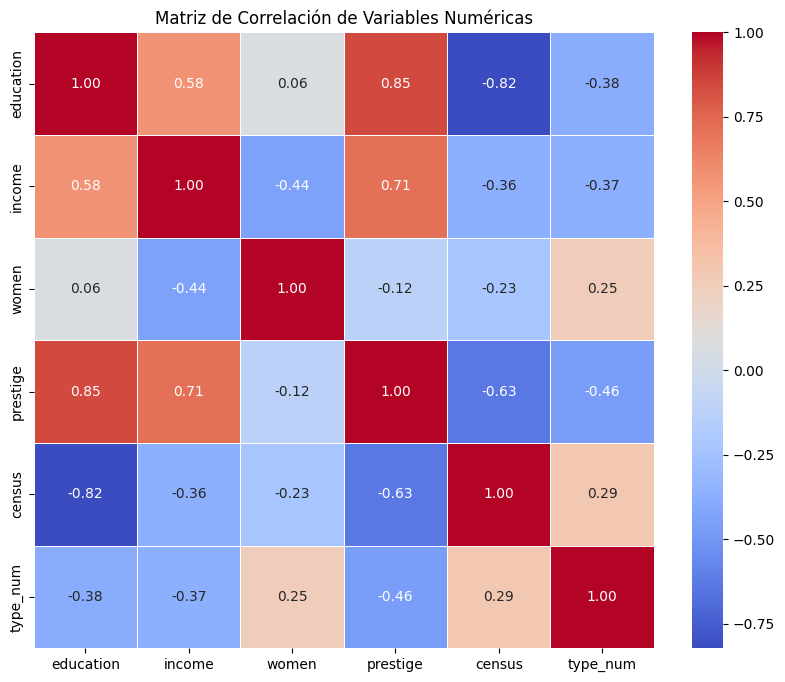

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [ ]:
print(matriz_correlacion)

           education    income     women  prestige    census  type_num
education   1.000000  0.577580  0.061853  0.850177 -0.823088 -0.381865
income      0.577580  1.000000 -0.441059  0.714906 -0.361002 -0.368360
women       0.061853 -0.441059  1.000000 -0.118334 -0.227003  0.250952
prestige    0.850177  0.714906 -0.118334  1.000000 -0.634510 -0.464762
census     -0.823088 -0.361002 -0.227003 -0.634510  1.000000  0.288078
type_num   -0.381865 -0.368360  0.250952 -0.464762  0.288078  1.000000


In [ ]:
display(df.describe())

,education,income,women,prestige,census,type_num
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,10.738039,6797.901961,28.979020,46.833333,5401.774510,1.843137
std,2.728444,4245.922227,31.724931,17.204486,2644.993215,0.817447
min,6.380000,611.000000,0.000000,14.800000,1113.000000,0.000000
25%,8.445000,4106.000000,3.592500,35.225000,3120.500000,1.000000
50%,10.540000,5930.500000,13.600000,43.600000,5135.000000,2.000000
75%,12.647500,8187.250000,52.202500,59.275000,8312.500000,2.000000
max,15.970000,25879.000000,97.510000,87.200000,9517.000000,3.000000


### Identificación de las variables con mayor correlación positiva

Vamos a analizar la matriz de correlación para encontrar las parejas de variables numéricas con la correlación positiva más alta.

In [3]:
import pandas as pd

# Load the dataset (from original cell qWQcbzaYMjS3)
url = "https://raw.githubusercontent.com/JoelRomero123/datamining/refs/heads/main/ARCHIVOS/Prestige_modificado.csv"
df = pd.read_csv(url, sep=';')

# Convert columns to numeric, coercing errors (from original cell qWQcbzaYMjS3)
numeric_cols = ['education', 'income', 'women', 'prestige', 'census', 'type_num']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Select numeric variables
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
# Calculate the correlation matrix
matriz_correlacion = variables_numericas.corr()

def get_highest_positive_correlations(corr_matrix, num_pairs=5):
    # Flatten the correlation matrix and get unique pairs
    corr_values = corr_matrix.unstack()
    # Filter out self-correlations and duplicate pairs
    corr_values = corr_values[corr_values.index.get_level_values(0) < corr_values.index.get_level_values(1)]

    # Sort in descending order to find highest positive correlations
    highest_corr = corr_values.sort_values(ascending=False)

    print(f"Las {num_pairs} parejas de variables con mayor correlación positiva son:")
    display(highest_corr.head(num_pairs))

get_highest_positive_correlations(matriz_correlacion, num_pairs=5)

Las 5 parejas de variables con mayor correlación positiva son:


,,0
education,prestige,0.850177
income,prestige,0.714906
education,income,0.577580
census,type_num,0.288078
type_num,women,0.250952


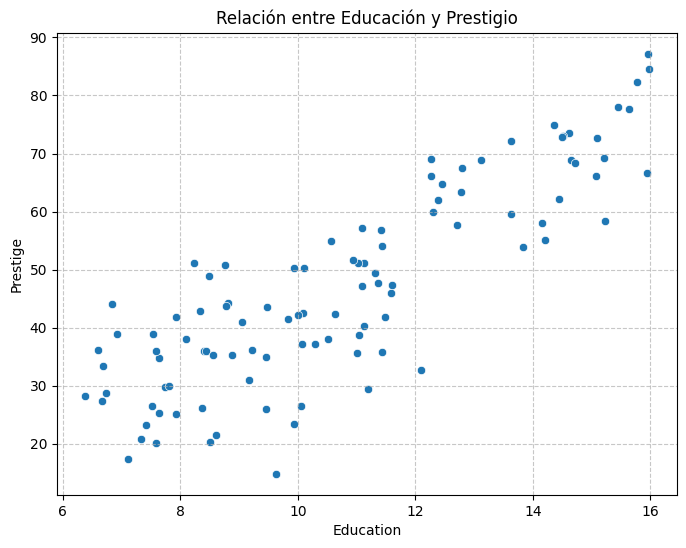

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='education', y='prestige', data=df)
plt.title('Relación entre Educación y Prestigio')
plt.xlabel('Education')
plt.ylabel('Prestige')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

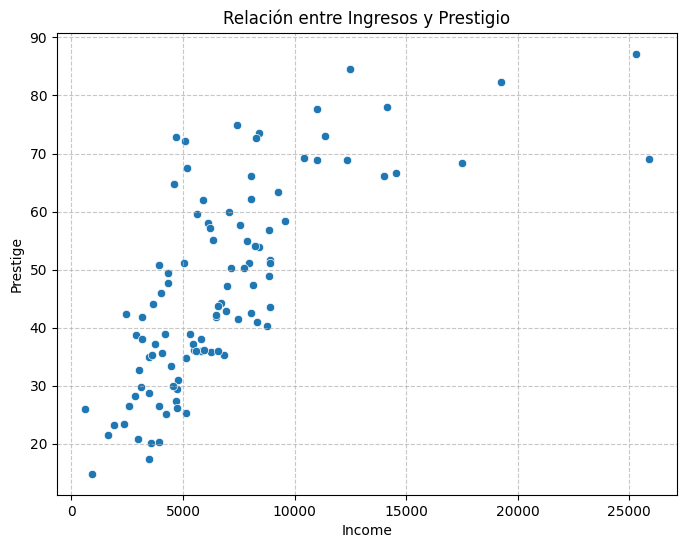

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='income', y='prestige', data=df)
plt.title('Relación entre Ingresos y Prestigio')
plt.xlabel('Income')
plt.ylabel('Prestige')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

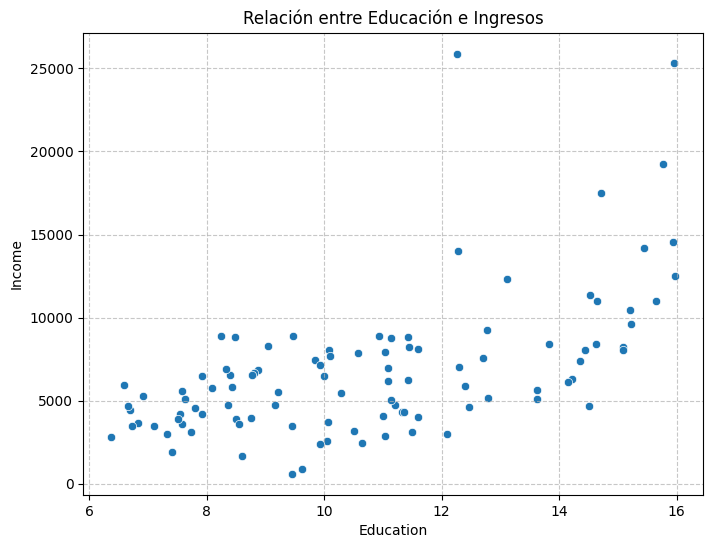

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='education', y='income', data=df)
plt.title('Relación entre Educación e Ingresos')
plt.xlabel('Education')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()